## Libraries

In [257]:
import os
import glob
import warnings
from tqdm import tqdm_notebook as tqdm
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import geopandas as gpd
from osgeo import gdal
import xarray as xr
import rioxarray as rxr
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

## Data processing

In [158]:
import re
def insert_space(text):
    return re.sub(r'([a-z](?=[A-Z])|[A-Z](?=[A-Z][a-z]))', r'\1 ', text)

poly = gpd.read_file('D:\Work\ADB\SAR\shapefiles\gadm41_VNM_1.json')
poly['VARNAME_1'] = poly['VARNAME_1'].apply(insert_space)
poly

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,VNM.1_1,VNM,Vietnam,AnGiang,An Giang,NA,Tỉnh,Province,NA,VN.AG,VN-44,"MULTIPOLYGON (((105.54860 10.42950, 105.54950 ..."
1,VNM.7_1,VNM,Vietnam,BàRịa-VũngTàu,Ba Ria - Vung Tau,NA,Tỉnh,Province,NA,VN.BV,NA,"MULTIPOLYGON (((107.09010 10.32400, 107.08890 ..."
2,VNM.3_1,VNM,Vietnam,BắcGiang,Bac Giang,NA,Tỉnh,Province,NA,VN.BG,NA,"MULTIPOLYGON (((106.28380 21.13230, 106.27340 ..."
3,VNM.4_1,VNM,Vietnam,BắcKạn,Bac Kan,NA,Tỉnh,Province,NA,VN.BK,NA,"MULTIPOLYGON (((105.87240 21.85580, 105.86290 ..."
4,VNM.2_1,VNM,Vietnam,BạcLiêu,Bac Lieu,NA,Tỉnh,Province,NA,VN.BL,NA,"MULTIPOLYGON (((105.42440 9.02130, 105.41640 9..."
...,...,...,...,...,...,...,...,...,...,...,...,...
58,VNM.59_1,VNM,Vietnam,TràVinh,Tra Vinh,NA,Tỉnh,Province,NA,VN.TV,NA,"MULTIPOLYGON (((106.41350 9.52920, 106.40880 9..."
59,VNM.60_1,VNM,Vietnam,TuyênQuang,Tuyen Quang,NA,Tỉnh,Province,NA,VN.TQ,NA,"MULTIPOLYGON (((105.51040 21.60470, 105.51410 ..."
60,VNM.61_1,VNM,Vietnam,VĩnhLong,Vinh Long,NA,Tỉnh,Province,NA,VN.VL,NA,"MULTIPOLYGON (((106.06320 9.94750, 106.06270 9..."
61,VNM.62_1,VNM,Vietnam,VĩnhPhúc,Vinh Phuc,NA,Tỉnh,Province,NA,VN.VC,NA,"MULTIPOLYGON (((105.57130 21.16150, 105.53360 ..."


In [194]:
paths = glob.glob('D:\Work\ADB\SAR\provincial_json_out/*.json')
# paths = [p for p in paths if '2015' not in p]
# paths = [p for p in paths if '2016' not in p]
# paths = [p for p in paths if '2020' not in p]
# paths = [p for p in paths if '.json' not in p]
paths

['D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2015-01-01.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2015-06-30.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2016-01-01.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2016-06-30.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2017-01-01.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2017-06-30.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2018-01-01.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2018-06-30.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2019-01-01.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2019-06-30.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2020-01-01.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2020-06-30.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2021-01-01.json',
 'D:\\Work\\ADB\\SAR\\provincial_json_out\\VNM.10_1_2021-06-30.json',
 'D:\\Work\\ADB\\SAR

In [213]:
list_gid_1 = []
list_date = []
list_dprvi = []
list_rvi = []
list_vvvh = []
list_vhvv = []
list_vv = []
list_vh = []

from tqdm import tqdm_notebook as tqdm
import json 

for path in tqdm(paths):
    with open(path, 'r') as in_file:
        j = json.load(in_file)
    list_gid_1.append(j['province_id'])
    list_date.append(j['date'])
    list_dprvi.append(j['DPRVI_mean'])
    list_rvi.append(j['RVI_mean'])
    list_vvvh.append(j['VVVH_mean'])
    list_vhvv.append(j['VHVV_mean'])
    list_vv.append(j['VV'])
    list_vh.append(j['VH'])

df = pd.DataFrame({'GID_1': list_gid_1,
                   'date': list_date,
                   'DPRVI_mean': list_dprvi,
                   'RVI_mean': list_rvi,
                   'VHVV_mean': list_vhvv,
                   'VVVH_mean': list_vvvh,
                   'VV': list_vv,
                   'VH': list_vh})
df = df.sort_values(by=['GID_1', 'date'])
df = pd.merge(df, poly[['GID_1', 'VARNAME_1']], on=['GID_1'], how='left')
df = df.rename({'VARNAME_1': 'Province'}, axis=1)
df['year'] = df['date'].str[:4]
df['year'] = df['year'].astype(int)
df = df.groupby(['Province', 'year']).agg({'DPRVI_mean': 'mean', 
                                           'RVI_mean': 'mean',
                                           'VH': 'mean',
                                           'VV': 'mean',
                                           'VHVV_mean': 'mean',
                                           'VVVH_mean': 'mean'}).reset_index()
df


  0%|          | 0/1007 [00:00<?, ?it/s]

,Province,year,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,An Giang,2015,0.451579,0.690742,0.030955,0.164481,0.214926,5.813418
1,An Giang,2016,0.465611,0.716257,0.030801,0.152360,0.225138,5.537533
2,An Giang,2017,0.464731,0.716017,0.032262,0.163144,0.225680,5.750358
3,An Giang,2018,0.445642,0.682234,0.029141,0.155650,0.212719,6.131314
4,An Giang,2019,0.426151,0.647307,0.028552,0.162450,0.199177,6.503130
...,...,...,...,...,...,...,...,...
499,Yen Bai,2018,0.471824,0.726092,0.035641,0.173111,0.228217,5.273289
500,Yen Bai,2019,0.448882,0.685187,0.033396,0.174277,0.212392,5.693736
501,Yen Bai,2020,0.435970,0.661552,0.031906,0.171271,0.203006,5.828146
502,Yen Bai,2021,0.434603,0.659285,0.032916,0.178219,0.202198,5.913466


In [214]:
# df = pd.read_csv('datasets/provincial_SAR.csv')
# df = pd.merge(df, poly[['GID_1', 'VARNAME_1']], on=['GID_1'], how='left')
# df = df.rename({'VARNAME_1': 'Province'}, axis=1)
# df['year'] = df['date'].str[:4]
# df['year'] = df['year'].astype(int)
# df = df.groupby(['Province', 'year']).agg({'DPRVI_mean': 'mean', 
#                                            'RVI_mean': 'mean',
#                                            'VH': 'mean',
#                                            'VV': 'mean',
#                                            'VHVV_mean': 'mean',
#                                            'VVVH_mean': 'mean'}).reset_index()
# df

In [197]:
spring_prod = pd.read_excel('D:\Work\ADB\SAR\datasets\Spring paddy production.xlsx')
spring_prod = pd.melt(spring_prod, id_vars=['Province'], 
                      var_name='year', 
                      value_vars=spring_prod.columns.to_list()[1:], 
                      value_name='spring_production')
spring_prod

,Province,year,spring_production
0,Ha Noi,2015,616.7
1,Vinh Phuc,2015,184.1
2,Bac Ninh,2015,237.4
3,Quang Ninh,2015,93.3
4,Hai Duong,2015,398.8
...,...,...,...
562,Can Tho,2023,559.8
563,Hau Giang,2023,585.4
564,Soc Trang,2023,1187.2
565,Bac Lieu,2023,335.7


In [198]:
spring_yield = pd.read_excel('D:\Work\ADB\SAR\datasets\Spring paddy yield.xlsx')
spring_yield = pd.melt(spring_yield, 
                       id_vars=['Province'], 
                       var_name='year', 
                       value_vars=spring_yield.columns.to_list()[1:], 
                       value_name='spring_yield')
spring_yield['year'] = spring_yield['year'].astype(int)
spring_yield

,Province,year,spring_yield
0,Ha Noi,2015,61.1
1,Vinh Phuc,2015,59.8
2,Bac Ninh,2015,65.9
3,Quang Ninh,2015,54.9
4,Hai Duong,2015,64.5
...,...,...,...
562,Can Tho,2023,NaN
563,Hau Giang,2023,NaN
564,Soc Trang,2023,NaN
565,Bac Lieu,2023,NaN


In [199]:
total_prod = pd.read_excel('D:\Work\ADB\SAR\datasets\Total paddy production.xlsx')
total_prod = pd.melt(total_prod, 
                     id_vars=['Province'], 
                     var_name='year', 
                     value_vars=total_prod.columns.to_list()[1:], 
                     value_name='total_production')
total_prod

,Province,year,total_production
0,Ha Noi,2015,1169.5
1,Vinh Phuc,2015,326.4
2,Bac Ninh,2015,444.8
3,Quang Ninh,2015,211.9
4,Hai Duong,2015,740.0
...,...,...,...
562,Can Tho,2023,1362.2
563,Hau Giang,2023,1186.7
564,Soc Trang,2023,2077.2
565,Bac Lieu,2023,1239.0


In [200]:
total_yield = pd.read_excel('D:\Work\ADB\SAR\datasets\Total paddy yield.xlsx')
total_yield = pd.melt(total_yield, 
                      id_vars=['Province'], 
                      var_name='year', 
                      value_vars=total_yield.columns.to_list()[1:], 
                      value_name='total_yield')
total_yield['year'] = total_yield['year'].astype(int)
total_yield

,Province,year,total_yield
0,Ha Noi,2015,58.3
1,Vinh Phuc,2015,55.9
2,Bac Ninh,2015,61.9
3,Quang Ninh,2015,49.9
4,Hai Duong,2015,60.3
...,...,...,...
562,Can Tho,2023,63.0
563,Hau Giang,2023,66.7
564,Soc Trang,2023,62.9
565,Bac Lieu,2023,64.7


In [201]:
winter_prod = pd.read_excel('D:\Work\ADB\SAR\datasets\Winter paddy production.xlsx')
winter_prod = pd.melt(winter_prod, 
                      id_vars=['Province'], 
                      var_name='year', 
                      value_vars=winter_prod.columns.to_list()[1:], 
                      value_name='winter_production')
winter_prod

,Province,year,winter_production
0,Ha Noi,2015,552.8
1,Vinh Phuc,2015,142.3
2,Bac Ninh,2015,207.4
3,Quang Ninh,2015,118.6
4,Hai Duong,2015,341.2
...,...,...,...
571,Can Tho,2023,NaN
572,Hau Giang,2023,NaN
573,Soc Trang,2023,55.8
574,Bac Lieu,2023,271.5


In [295]:
winter_yield = pd.read_excel('D:\Work\ADB\SAR\datasets\Winter paddy yield.xlsx')
winter_yield = pd.melt(winter_yield, 
                       id_vars=['Province'], 
                       var_name='year', 
                       value_vars=winter_yield.columns.to_list()[1:], 
                       value_name='winter_yield')
winter_yield['year'] = winter_yield['year'].astype(int)
winter_yield

,Province,year,winter_yield
0,Ha Noi,2015,55.5
1,Vinh Phuc,2015,51.6
2,Bac Ninh,2015,57.8
3,Quang Ninh,2015,46.5
4,Hai Duong,2015,56.0
...,...,...,...
562,Can Tho,2023,NaN
563,Hau Giang,2023,NaN
564,Soc Trang,2023,51.2
565,Bac Lieu,2023,58.4


In [203]:
autumn_prod = pd.read_excel('D:\Work\ADB\SAR\datasets\Autumn paddy production.xlsx')
autumn_prod = pd.melt(autumn_prod, 
                      id_vars=['Province'], 
                      var_name='year', 
                      value_vars=autumn_prod.columns.to_list()[1:], 
                      value_name='autumn_production')
autumn_prod

,Province,year,autumn_production
0,Nghe An,2015,275.0
1,Ha Tinh,2015,203.9
2,Quang Binh,2015,94.6
3,Quang Tri,2015,99.0
4,Thua Thien Hue,2015,150.7
...,...,...,...
283,Can Tho,Prel. 2023,802.4
284,Hau Giang,Prel. 2023,601.3
285,Soc Trang,Prel. 2023,834.2
286,Bac Lieu,Prel. 2023,631.8


In [204]:
autumn_yield = pd.read_excel('D:\Work\ADB\SAR\datasets\Autumn paddy yield.xlsx')
autumn_yield = pd.melt(autumn_yield, 
                      id_vars=['Province'], 
                      var_name='year', 
                      value_vars=autumn_yield.columns.to_list()[1:], 
                      value_name='autumn_yield')
autumn_yield

,Province,year,autumn_yield
0,Nghe An,2015,49.5
1,Ha Tinh,2015,48.5
2,Quang Binh,2015,40.3
3,Quang Tri,2015,49.3
4,Thua Thien Hue,2015,58.2
...,...,...,...
283,Can Tho,2023,56.8
284,Hau Giang,2023,58.8
285,Soc Trang,2023,57.5
286,Bac Lieu,2023,62.1


In [209]:
df

,Province,year,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,An Giang,2018,0.445642,0.682234,0.029141,0.155650,0.212719,6.131314
1,An Giang,2021,0.423400,0.644014,0.029360,0.169887,0.198705,6.803089
2,An Giang,2022,0.429624,0.653545,0.031288,0.174996,0.201566,6.546483
3,Ba Ria - Vung Tau,2018,0.478448,0.741097,0.035244,0.168271,0.235781,5.410327
4,Ba Ria - Vung Tau,2021,0.441159,0.671443,0.034025,0.181704,0.207056,5.954155
...,...,...,...,...,...,...,...,...
184,Vinh Phuc,2021,0.458182,0.699343,0.034942,0.177928,0.216624,5.410783
185,Vinh Phuc,2022,0.456538,0.696039,0.036610,0.185891,0.215139,5.427283
186,Yen Bai,2018,0.471824,0.726092,0.035641,0.173111,0.228217,5.273289
187,Yen Bai,2021,0.434603,0.659285,0.032916,0.178219,0.202198,5.913466


In [296]:
df_full = df.copy(deep=True)

for df_ in [spring_prod, spring_yield, autumn_prod, autumn_yield, winter_prod, winter_yield, total_prod, total_yield]:
    df_full = pd.merge(df_full, df_, on=['Province', 'year'], how='left')

## EDA

In [297]:
df_full

,Province,year,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean,spring_production,spring_yield,autumn_production,autumn_yield,winter_production,winter_yield,total_production,total_yield
0,An Giang,2015,0.451579,0.690742,0.030955,0.164481,0.214926,5.813418,1804.4,75.6,2250.1,56.2,19.2,36.2,4073.7,63.2
1,An Giang,2016,0.465611,0.716257,0.030801,0.152360,0.225138,5.537533,1719.9,71.9,2234.6,52.6,20.1,40.2,3974.7,59.4
2,An Giang,2017,0.464731,0.716017,0.032262,0.163144,0.225680,5.750358,1660.4,70.3,2202.0,55.1,17.2,34.4,3879.6,60.5
3,An Giang,2018,0.445642,0.682234,0.029141,0.155650,0.212719,6.131314,1727.4,73.5,2199.1,56.7,0.3,30.0,3926.9,63.0
4,An Giang,2019,0.426151,0.647307,0.028552,0.162450,0.199177,6.503130,1659.3,71.0,2241.0,57.8,19.0,39.6,3919.3,62.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,Yen Bai,2018,0.471824,0.726092,0.035641,0.173111,0.228217,5.273289,108.4,55.0,NaN,NaN,101.6,45.4,210.0,49.9
500,Yen Bai,2019,0.448882,0.685187,0.033396,0.174277,0.212392,5.693736,108.3,55.3,NaN,NaN,107.2,46.2,215.5,50.4
501,Yen Bai,2020,0.435970,0.661552,0.031906,0.171271,0.203006,5.828146,109.2,55.4,NaN,NaN,108.5,46.8,217.7,50.7
502,Yen Bai,2021,0.434603,0.659285,0.032916,0.178219,0.202198,5.913466,109.0,55.8,NaN,NaN,109.3,47.3,218.3,51.2


### Distribution

In [298]:
df_full.describe()

,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean,spring_production,spring_yield,autumn_production,autumn_yield,winter_production,winter_yield,total_production,total_yield
count,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,493.000000,493.000000,232.000000,232.000000,456.000000,456.000000,496.000000,496.000000
mean,0.447293,0.680840,0.039087,0.209907,0.210025,5.751271,327.600000,61.281542,518.545259,53.496121,143.121491,44.889693,699.772379,54.933871
std,0.023468,0.041251,0.007453,0.043644,0.015807,0.814731,416.619563,8.884380,619.066974,7.149476,135.321484,12.606958,885.051062,8.136821
min,0.389301,0.579864,0.025259,0.128684,0.172454,4.520520,0.200000,0.400000,4.600000,34.000000,0.300000,6.000000,25.000000,21.100000
25%,0.430521,0.651470,0.033618,0.176903,0.198582,5.242261,79.800000,56.900000,112.750000,49.500000,34.425000,37.800000,206.850000,50.900000
50%,0.446503,0.678064,0.037711,0.207506,0.208862,5.664595,198.700000,61.300000,230.550000,54.650000,115.550000,47.950000,384.000000,56.800000
75%,0.462441,0.707743,0.044361,0.236450,0.219806,6.084743,357.100000,66.800000,719.900000,58.000000,201.625000,54.550000,836.775000,60.600000
max,0.509071,0.794074,0.064367,0.369887,0.255307,14.833086,2224.500000,78.200000,2350.800000,73.100000,697.800000,65.000000,4643.000000,71.200000


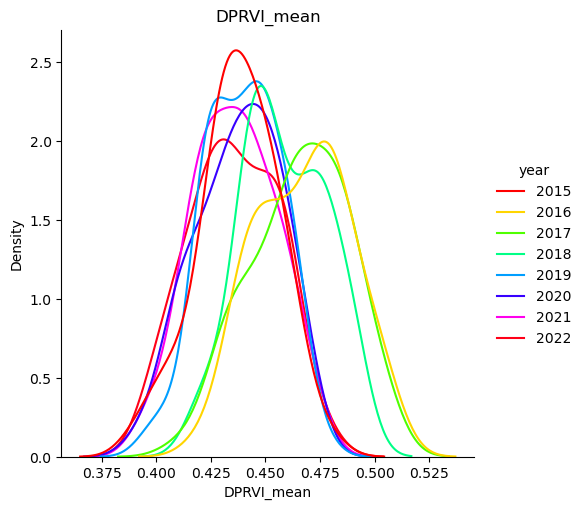

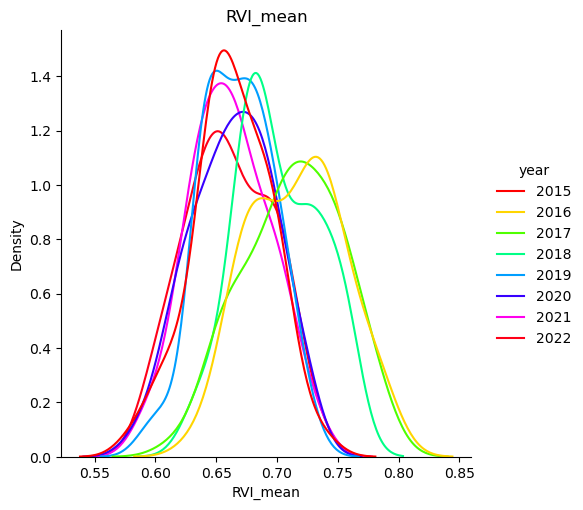

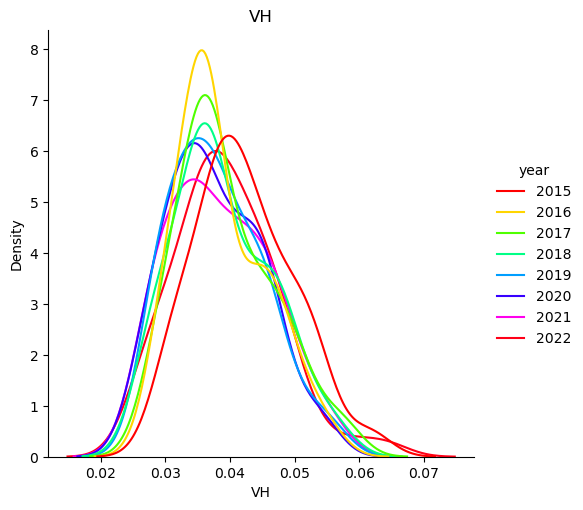

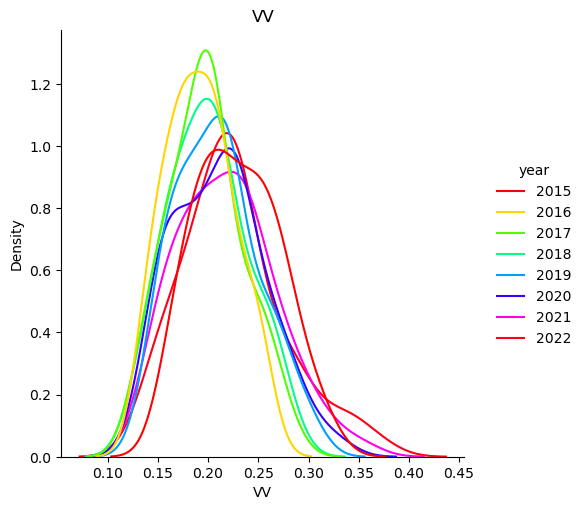

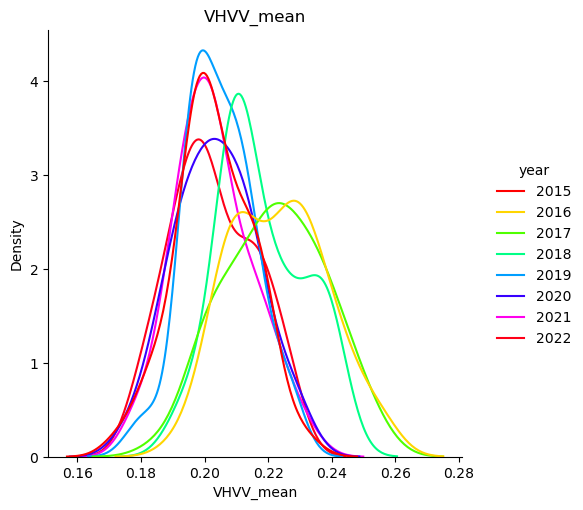

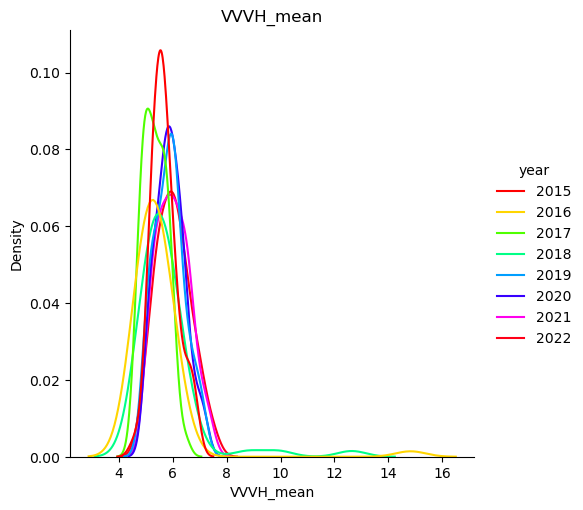

In [299]:
for indicator in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    sns.displot(data=df_full, x=indicator, kind="kde", hue='year', palette='hsv')
    plt.title(indicator)

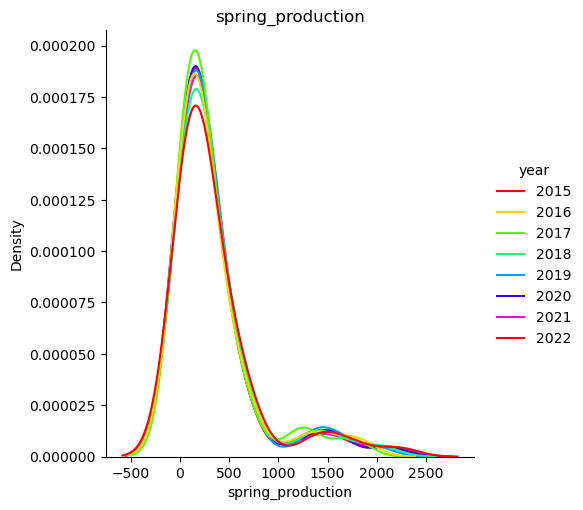

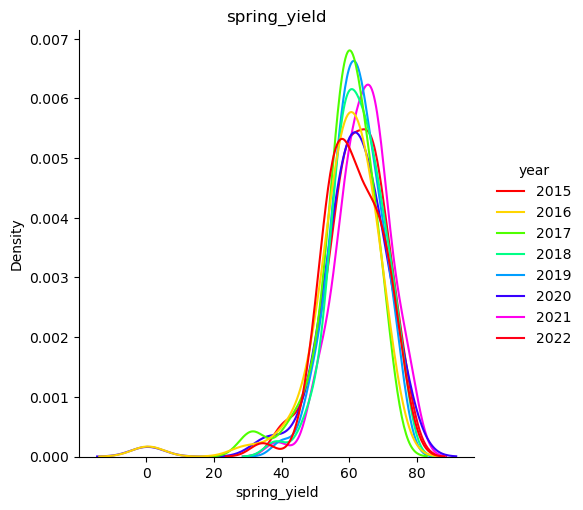

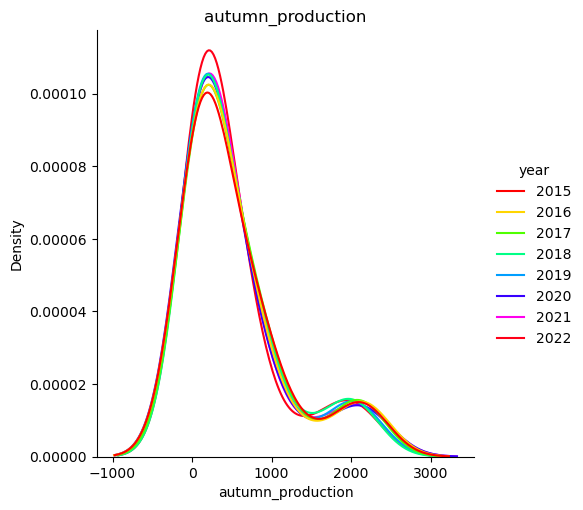

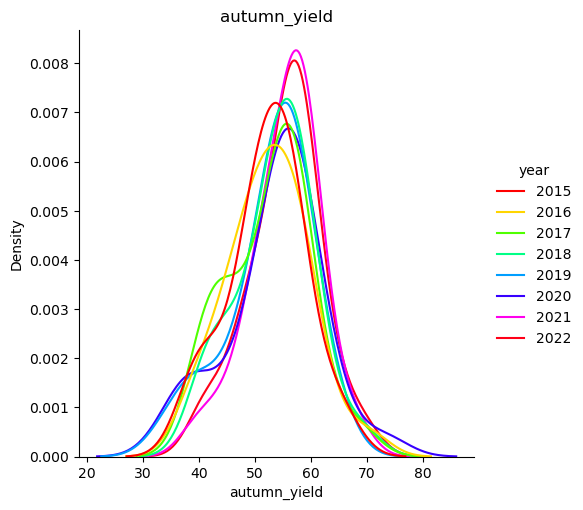

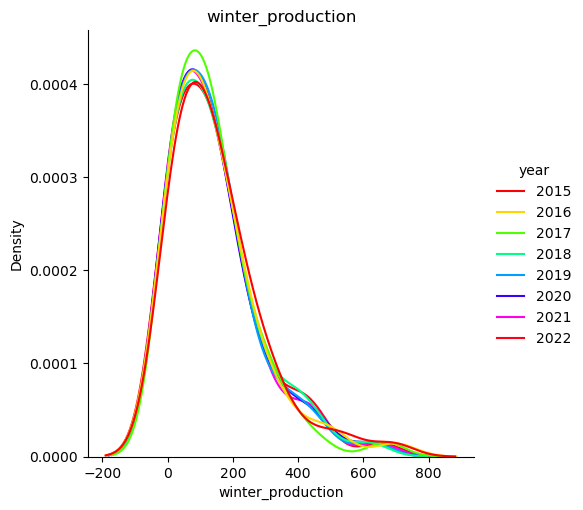

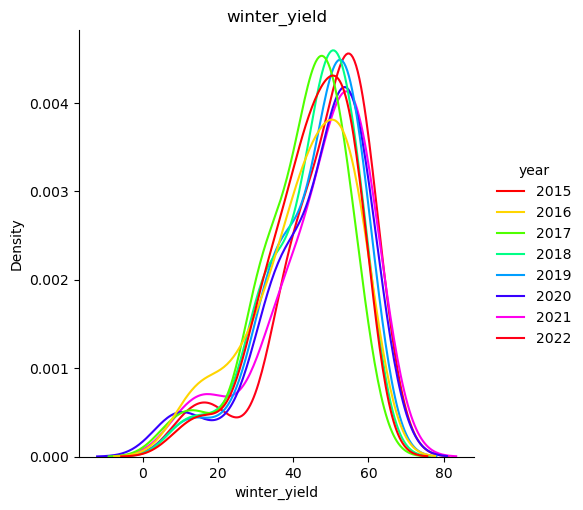

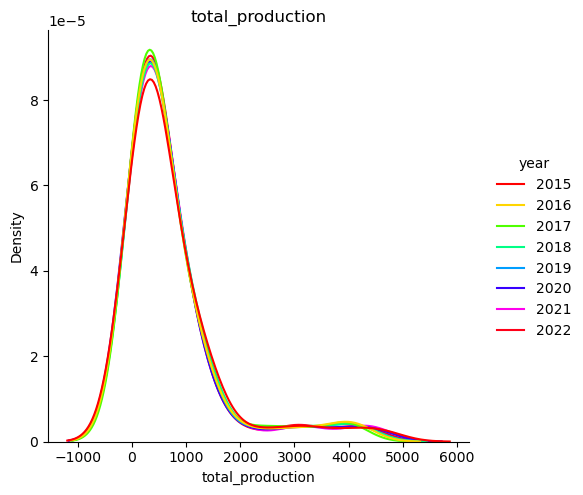

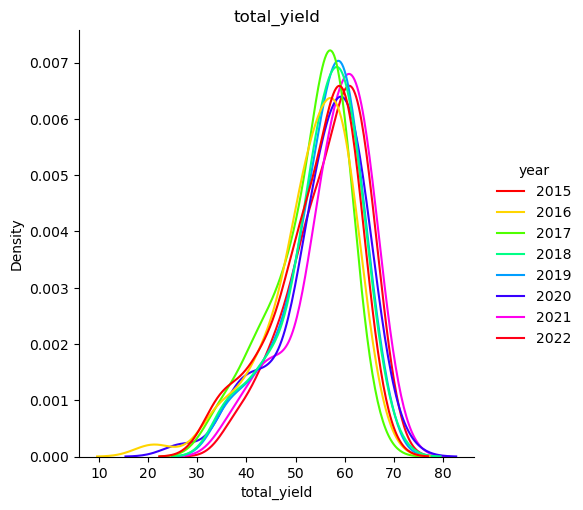

In [300]:
for metric in ['spring_production', 'spring_yield', 'autumn_production',
       'autumn_yield', 'winter_production', 'winter_yield', 'total_production',
       'total_yield']:
    sns.displot(data=df_full, x=metric, kind="kde", hue='year', palette='hsv')
    plt.title(metric)

### Choropleth

In [301]:
df_choro = gpd.GeoDataFrame(pd.merge(df_full, poly[['VARNAME_1', 'geometry']], left_on='Province', right_on='VARNAME_1', how='left'))
df_choro.head()

,Province,year,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean,spring_production,spring_yield,autumn_production,autumn_yield,winter_production,winter_yield,total_production,total_yield,VARNAME_1,geometry
0,An Giang,2015,0.451579,0.690742,0.030955,0.164481,0.214926,5.813418,1804.4,75.6,2250.1,56.2,19.2,36.2,4073.7,63.2,An Giang,"MULTIPOLYGON (((105.54860 10.42950, 105.54950 ..."
1,An Giang,2016,0.465611,0.716257,0.030801,0.152360,0.225138,5.537533,1719.9,71.9,2234.6,52.6,20.1,40.2,3974.7,59.4,An Giang,"MULTIPOLYGON (((105.54860 10.42950, 105.54950 ..."
2,An Giang,2017,0.464731,0.716017,0.032262,0.163144,0.225680,5.750358,1660.4,70.3,2202.0,55.1,17.2,34.4,3879.6,60.5,An Giang,"MULTIPOLYGON (((105.54860 10.42950, 105.54950 ..."
3,An Giang,2018,0.445642,0.682234,0.029141,0.155650,0.212719,6.131314,1727.4,73.5,2199.1,56.7,0.3,30.0,3926.9,63.0,An Giang,"MULTIPOLYGON (((105.54860 10.42950, 105.54950 ..."
4,An Giang,2019,0.426151,0.647307,0.028552,0.162450,0.199177,6.503130,1659.3,71.0,2241.0,57.8,19.0,39.6,3919.3,62.6,An Giang,"MULTIPOLYGON (((105.54860 10.42950, 105.54950 ..."


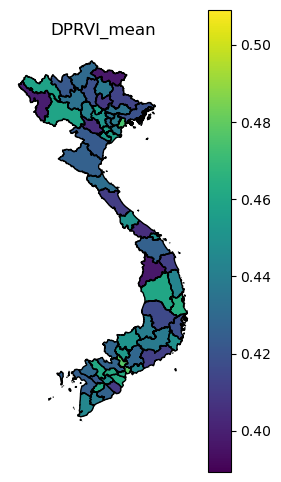

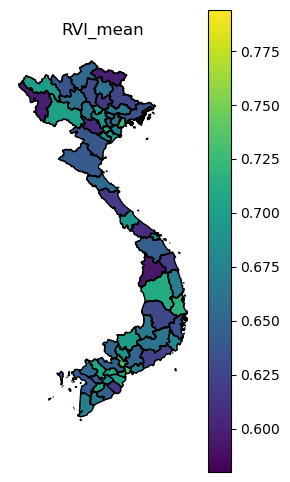

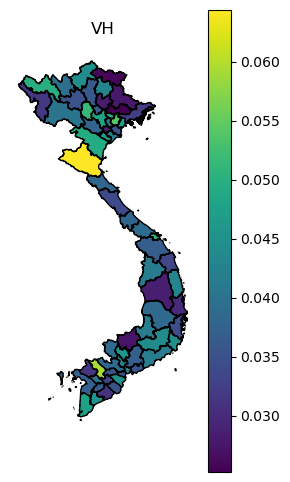

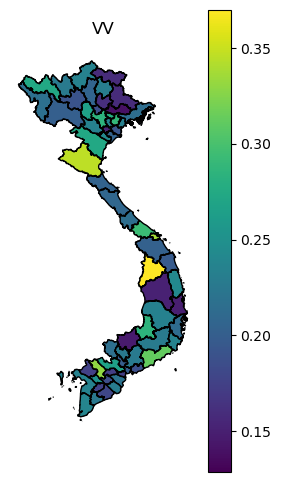

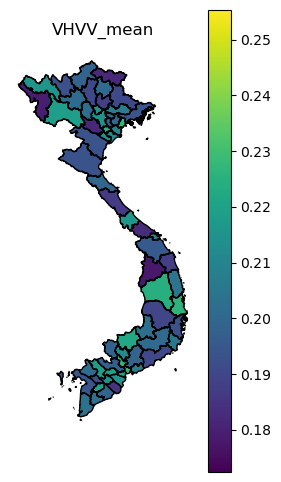

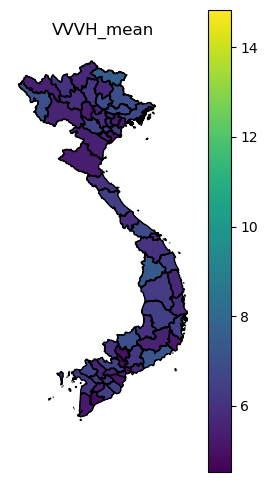

In [302]:
for indicator in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    fig, ax = plt.subplots(figsize=(3, 6))
    df_choro.plot(column=indicator, legend=True, ax=ax)
    poly.plot(ax=ax, facecolor='none', edgecolor='k')
    plt.title(indicator)
    ax.set_axis_off()

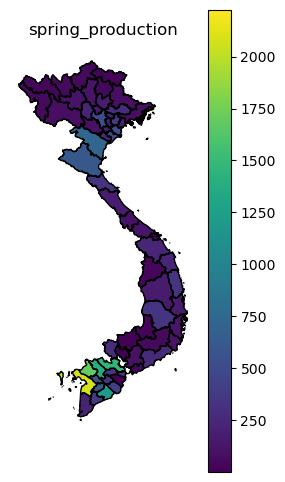

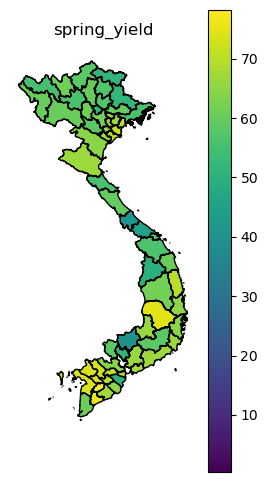

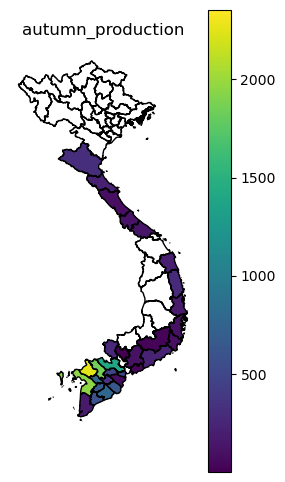

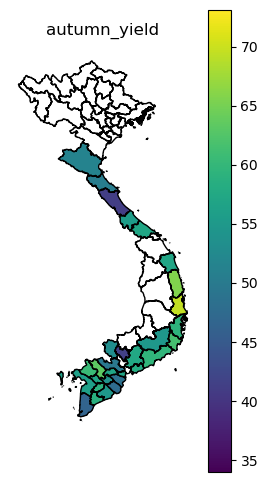

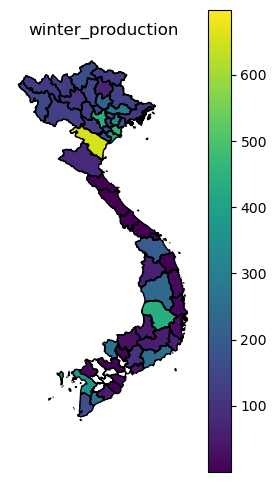

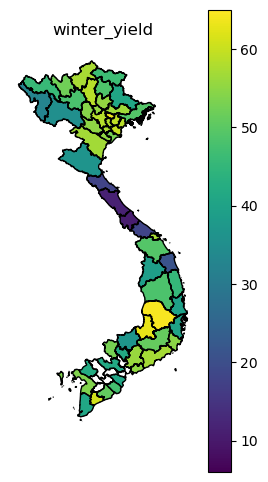

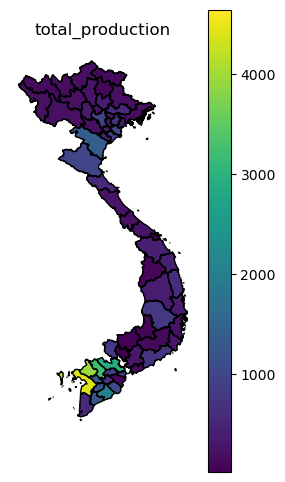

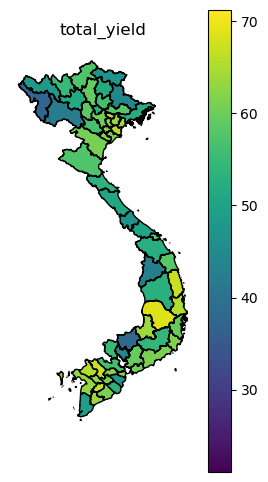

In [303]:
for metric in ['spring_production', 'spring_yield', 'autumn_production',
       'autumn_yield', 'winter_production', 'winter_yield', 'total_production',
       'total_yield']:
    fig, ax = plt.subplots(figsize=(3, 6))
    df_choro.plot(column=metric, legend=True, ax=ax)
    poly.plot(ax=ax, facecolor='none', edgecolor='k')
    plt.title(metric)
    ax.set_axis_off()

In [304]:
df_full.columns

Index(['Province', 'year', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean', 'spring_production', 'spring_yield', 'autumn_production',
       'autumn_yield', 'winter_production', 'winter_yield', 'total_production',
       'total_yield'],
      dtype='object')

## Modeling

In [305]:
import statsmodels.api as sm
import linearmodels as lm
from bs4 import BeautifulSoup
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

### Total yield

In [306]:
df_model = df_full[['Province', 'year', 'total_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,total_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,An Giang,2015,63.2,0.451579,0.690742,0.030955,0.164481,0.214926,5.813418
1,An Giang,2016,59.4,0.465611,0.716257,0.030801,0.152360,0.225138,5.537533
2,An Giang,2017,60.5,0.464731,0.716017,0.032262,0.163144,0.225680,5.750358
3,An Giang,2018,63.0,0.445642,0.682234,0.029141,0.155650,0.212719,6.131314
4,An Giang,2019,62.6,0.426151,0.647307,0.028552,0.162450,0.199177,6.503130
...,...,...,...,...,...,...,...,...,...
490,Yen Bai,2018,49.9,0.471824,0.726092,0.035641,0.173111,0.228217,5.273289
491,Yen Bai,2019,50.4,0.448882,0.685187,0.033396,0.174277,0.212392,5.693736
492,Yen Bai,2020,50.7,0.435970,0.661552,0.031906,0.171271,0.203006,5.828146
493,Yen Bai,2021,51.2,0.434603,0.659285,0.032916,0.178219,0.202198,5.913466


In [307]:
Y = df_model['total_yield']

for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
    print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            total_yield   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.4412
Date:                Fri, 16 Aug 2024   Prob (F-statistic):              0.507
Time:                        11:45:57   Log-Likelihood:                -1739.7
No. Observations:                 495   AIC:                             3483.
Df Residuals:                     493   BIC:                             3492.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.6232      7.979      6.219      0.0

In [308]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['total_yield']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    print(results.summary)

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

                          PanelOLS Estimation Summary                           
Dep. Variable:            total_yield   R-squared:                        0.3786
Estimator:                   PanelOLS   R-squared (Between):              0.0300
No. Observations:                 495   R-squared (Within):               0.3786
Date:                Fri, Aug 16 2024   R-squared (Overall):              0.0308
Time:                        11:45:57   Log-likelihood                   -1038.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      32.361
Entities:                          62   P-value                           0.0000
Avg Obs:                       7.9839   Distribution:                   F(8,425)
Min Obs:                       7.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             42.932
                            

### Total production

In [309]:
df_model = df_full[['Province', 'year', 'total_production', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,total_production,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,An Giang,2015,4073.7,0.451579,0.690742,0.030955,0.164481,0.214926,5.813418
1,An Giang,2016,3974.7,0.465611,0.716257,0.030801,0.152360,0.225138,5.537533
2,An Giang,2017,3879.6,0.464731,0.716017,0.032262,0.163144,0.225680,5.750358
3,An Giang,2018,3926.9,0.445642,0.682234,0.029141,0.155650,0.212719,6.131314
4,An Giang,2019,3919.3,0.426151,0.647307,0.028552,0.162450,0.199177,6.503130
...,...,...,...,...,...,...,...,...,...
490,Yen Bai,2018,210.0,0.471824,0.726092,0.035641,0.173111,0.228217,5.273289
491,Yen Bai,2019,215.5,0.448882,0.685187,0.033396,0.174277,0.212392,5.693736
492,Yen Bai,2020,217.7,0.435970,0.661552,0.031906,0.171271,0.203006,5.828146
493,Yen Bai,2021,218.3,0.434603,0.659285,0.032916,0.178219,0.202198,5.913466


In [310]:
Y = df_model['total_production']

for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
    print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       total_production   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.1513
Date:                Fri, 16 Aug 2024   Prob (F-statistic):              0.698
Time:                        11:45:57   Log-Likelihood:                -4061.1
No. Observations:                 495   AIC:                             8126.
Df Residuals:                     493   BIC:                             8135.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        416.0491    734.473      0.566      0.5

In [311]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['total_production']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    print(results.summary)

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

                          PanelOLS Estimation Summary                           
Dep. Variable:       total_production   R-squared:                        0.0566
Estimator:                   PanelOLS   R-squared (Between):             -0.1405
No. Observations:                 495   R-squared (Within):               0.0566
Date:                Fri, Aug 16 2024   R-squared (Overall):             -0.1399
Time:                        11:45:57   Log-likelihood                   -2659.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.1850
Entities:                          62   P-value                           0.0016
Avg Obs:                       7.9839   Distribution:                   F(8,425)
Min Obs:                       7.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             4.3972
                            

### Spring yield

In [312]:
df_model = df_full[['Province', 'year', 'spring_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,spring_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,An Giang,2015,75.6,0.451579,0.690742,0.030955,0.164481,0.214926,5.813418
1,An Giang,2016,71.9,0.465611,0.716257,0.030801,0.152360,0.225138,5.537533
2,An Giang,2017,70.3,0.464731,0.716017,0.032262,0.163144,0.225680,5.750358
3,An Giang,2018,73.5,0.445642,0.682234,0.029141,0.155650,0.212719,6.131314
4,An Giang,2019,71.0,0.426151,0.647307,0.028552,0.162450,0.199177,6.503130
...,...,...,...,...,...,...,...,...,...
487,Yen Bai,2018,55.0,0.471824,0.726092,0.035641,0.173111,0.228217,5.273289
488,Yen Bai,2019,55.3,0.448882,0.685187,0.033396,0.174277,0.212392,5.693736
489,Yen Bai,2020,55.4,0.435970,0.661552,0.031906,0.171271,0.203006,5.828146
490,Yen Bai,2021,55.8,0.434603,0.659285,0.032916,0.178219,0.202198,5.913466


In [313]:
Y = df_model['spring_yield']

for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
    print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           spring_yield   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.5728
Date:                Fri, 16 Aug 2024   Prob (F-statistic):              0.450
Time:                        11:45:57   Log-Likelihood:                -1772.5
No. Observations:                 492   AIC:                             3549.
Df Residuals:                     490   BIC:                             3557.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         55.4994      7.552      7.349      0.0

In [314]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['spring_yield']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    print(results.summary)

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

                          PanelOLS Estimation Summary                           
Dep. Variable:           spring_yield   R-squared:                        0.1494
Estimator:                   PanelOLS   R-squared (Between):              0.3440
No. Observations:                 492   R-squared (Within):               0.1494
Date:                Fri, Aug 16 2024   R-squared (Overall):              0.3427
Time:                        11:45:57   Log-likelihood                   -1375.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      9.2656
Entities:                          62   P-value                           0.0000
Avg Obs:                       7.9355   Distribution:                   F(8,422)
Min Obs:                       5.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             12.222
                            

### Spring production

In [315]:
df_model = df_full[['Province', 'year', 'spring_production', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,spring_production,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,An Giang,2015,1804.4,0.451579,0.690742,0.030955,0.164481,0.214926,5.813418
1,An Giang,2016,1719.9,0.465611,0.716257,0.030801,0.152360,0.225138,5.537533
2,An Giang,2017,1660.4,0.464731,0.716017,0.032262,0.163144,0.225680,5.750358
3,An Giang,2018,1727.4,0.445642,0.682234,0.029141,0.155650,0.212719,6.131314
4,An Giang,2019,1659.3,0.426151,0.647307,0.028552,0.162450,0.199177,6.503130
...,...,...,...,...,...,...,...,...,...
487,Yen Bai,2018,108.4,0.471824,0.726092,0.035641,0.173111,0.228217,5.273289
488,Yen Bai,2019,108.3,0.448882,0.685187,0.033396,0.174277,0.212392,5.693736
489,Yen Bai,2020,109.2,0.435970,0.661552,0.031906,0.171271,0.203006,5.828146
490,Yen Bai,2021,109.0,0.434603,0.659285,0.032916,0.178219,0.202198,5.913466


In [316]:
Y = df_model['spring_production']

for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
    print(results.summary())

                            OLS Regression Results                            
Dep. Variable:      spring_production   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.1705
Date:                Fri, 16 Aug 2024   Prob (F-statistic):              0.680
Time:                        11:45:57   Log-Likelihood:                -3665.8
No. Observations:                 492   AIC:                             7336.
Df Residuals:                     490   BIC:                             7344.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        190.0593    336.239      0.565      0.5

In [317]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['spring_production']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    print(results.summary)

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

                          PanelOLS Estimation Summary                           
Dep. Variable:      spring_production   R-squared:                        0.0803
Estimator:                   PanelOLS   R-squared (Between):             -0.0335
No. Observations:                 492   R-squared (Within):               0.0803
Date:                Fri, Aug 16 2024   R-squared (Overall):             -0.0329
Time:                        11:45:57   Log-likelihood                   -2393.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.6059
Entities:                          62   P-value                           0.0000
Avg Obs:                       7.9355   Distribution:                   F(8,422)
Min Obs:                       5.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             4.3813
                            

### Autumn yield

In [318]:
df_model = df_full[['Province', 'year', 'autumn_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,autumn_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,An Giang,2015,56.2,0.451579,0.690742,0.030955,0.164481,0.214926,5.813418
1,An Giang,2016,52.6,0.465611,0.716257,0.030801,0.152360,0.225138,5.537533
2,An Giang,2017,55.1,0.464731,0.716017,0.032262,0.163144,0.225680,5.750358
3,An Giang,2018,56.7,0.445642,0.682234,0.029141,0.155650,0.212719,6.131314
4,An Giang,2019,57.8,0.426151,0.647307,0.028552,0.162450,0.199177,6.503130
...,...,...,...,...,...,...,...,...,...
227,Vinh Long,2018,56.5,0.473459,0.731108,0.031662,0.155026,0.231329,5.504908
228,Vinh Long,2019,56.1,0.443176,0.675468,0.030758,0.161618,0.208862,5.921092
229,Vinh Long,2020,57.3,0.454628,0.696261,0.031365,0.163036,0.217105,5.716588
230,Vinh Long,2021,55.4,0.439760,0.670493,0.029397,0.167454,0.207638,6.056024


In [319]:
Y = df_model['autumn_yield']

for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
    print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           autumn_yield   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7097
Date:                Fri, 16 Aug 2024   Prob (F-statistic):              0.400
Time:                        11:45:58   Log-Likelihood:                -784.65
No. Observations:                 232   AIC:                             1573.
Df Residuals:                     230   BIC:                             1580.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         44.9646     10.027      4.484      0.0

In [320]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['autumn_yield']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    print(results.summary)

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

                          PanelOLS Estimation Summary                           
Dep. Variable:           autumn_yield   R-squared:                        0.2703
Estimator:                   PanelOLS   R-squared (Between):             -0.3746
No. Observations:                 232   R-squared (Within):               0.2703
Date:                Fri, Aug 16 2024   R-squared (Overall):             -0.3733
Time:                        11:45:58   Log-likelihood                   -495.17
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      9.0273
Entities:                          29   P-value                           0.0000
Avg Obs:                       8.0000   Distribution:                   F(8,195)
Min Obs:                       8.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             12.359
                            

### Autumn production

In [321]:
df_model = df_full[['Province', 'year', 'autumn_production', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,autumn_production,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,An Giang,2015,2250.1,0.451579,0.690742,0.030955,0.164481,0.214926,5.813418
1,An Giang,2016,2234.6,0.465611,0.716257,0.030801,0.152360,0.225138,5.537533
2,An Giang,2017,2202.0,0.464731,0.716017,0.032262,0.163144,0.225680,5.750358
3,An Giang,2018,2199.1,0.445642,0.682234,0.029141,0.155650,0.212719,6.131314
4,An Giang,2019,2241.0,0.426151,0.647307,0.028552,0.162450,0.199177,6.503130
...,...,...,...,...,...,...,...,...,...
227,Vinh Long,2018,597.7,0.473459,0.731108,0.031662,0.155026,0.231329,5.504908
228,Vinh Long,2019,562.6,0.443176,0.675468,0.030758,0.161618,0.208862,5.921092
229,Vinh Long,2020,534.8,0.454628,0.696261,0.031365,0.163036,0.217105,5.716588
230,Vinh Long,2021,482.6,0.439760,0.670493,0.029397,0.167454,0.207638,6.056024


In [322]:
Y = df_model['autumn_production']

for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
    print(results.summary())

                            OLS Regression Results                            
Dep. Variable:      autumn_production   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                   0.09527
Date:                Fri, 16 Aug 2024   Prob (F-statistic):              0.758
Time:                        11:45:58   Log-Likelihood:                -1820.0
No. Observations:                 232   AIC:                             3644.
Df Residuals:                     230   BIC:                             3651.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        255.8911    850.803      0.301      0.7

In [323]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['autumn_production']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    print(results.summary)

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

                          PanelOLS Estimation Summary                           
Dep. Variable:      autumn_production   R-squared:                        0.0631
Estimator:                   PanelOLS   R-squared (Between):             -0.1116
No. Observations:                 232   R-squared (Within):               0.0631
Date:                Fri, Aug 16 2024   R-squared (Overall):             -0.1111
Time:                        11:45:58   Log-likelihood                   -1191.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.6410
Entities:                          29   P-value                           0.1154
Avg Obs:                       8.0000   Distribution:                   F(8,195)
Min Obs:                       8.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             5.2004
                            

### Winter yield

In [324]:
df_model = df_full[['Province', 'year', 'winter_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,winter_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,An Giang,2015,36.2,0.451579,0.690742,0.030955,0.164481,0.214926,5.813418
1,An Giang,2016,40.2,0.465611,0.716257,0.030801,0.152360,0.225138,5.537533
2,An Giang,2017,34.4,0.464731,0.716017,0.032262,0.163144,0.225680,5.750358
3,An Giang,2018,30.0,0.445642,0.682234,0.029141,0.155650,0.212719,6.131314
4,An Giang,2019,39.6,0.426151,0.647307,0.028552,0.162450,0.199177,6.503130
...,...,...,...,...,...,...,...,...,...
450,Yen Bai,2018,45.4,0.471824,0.726092,0.035641,0.173111,0.228217,5.273289
451,Yen Bai,2019,46.2,0.448882,0.685187,0.033396,0.174277,0.212392,5.693736
452,Yen Bai,2020,46.8,0.435970,0.661552,0.031906,0.171271,0.203006,5.828146
453,Yen Bai,2021,47.3,0.434603,0.659285,0.032916,0.178219,0.202198,5.913466


In [325]:
Y = df_model['winter_yield']

for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
    print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           winter_yield   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6017
Date:                Fri, 16 Aug 2024   Prob (F-statistic):              0.438
Time:                        11:45:58   Log-Likelihood:                -1798.1
No. Observations:                 455   AIC:                             3600.
Df Residuals:                     453   BIC:                             3608.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         35.5854     12.097      2.942      0.0

In [326]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['winter_yield']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    print(results.summary)

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

                          PanelOLS Estimation Summary                           
Dep. Variable:           winter_yield   R-squared:                        0.2355
Estimator:                   PanelOLS   R-squared (Between):             -0.3249
No. Observations:                 455   R-squared (Within):               0.2355
Date:                Fri, Aug 16 2024   R-squared (Overall):             -0.3215
Time:                        11:45:58   Log-likelihood                   -1167.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      15.016
Entities:                          57   P-value                           0.0000
Avg Obs:                       7.9825   Distribution:                   F(8,390)
Min Obs:                       7.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             11.108
                            

### Winter production

In [327]:
df_model = df_full[['Province', 'year', 'winter_production', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,winter_production,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,An Giang,2015,19.2,0.451579,0.690742,0.030955,0.164481,0.214926,5.813418
1,An Giang,2016,20.1,0.465611,0.716257,0.030801,0.152360,0.225138,5.537533
2,An Giang,2017,17.2,0.464731,0.716017,0.032262,0.163144,0.225680,5.750358
3,An Giang,2018,0.3,0.445642,0.682234,0.029141,0.155650,0.212719,6.131314
4,An Giang,2019,19.0,0.426151,0.647307,0.028552,0.162450,0.199177,6.503130
...,...,...,...,...,...,...,...,...,...
450,Yen Bai,2018,101.6,0.471824,0.726092,0.035641,0.173111,0.228217,5.273289
451,Yen Bai,2019,107.2,0.448882,0.685187,0.033396,0.174277,0.212392,5.693736
452,Yen Bai,2020,108.5,0.435970,0.661552,0.031906,0.171271,0.203006,5.828146
453,Yen Bai,2021,109.3,0.434603,0.659285,0.032916,0.178219,0.202198,5.913466


In [328]:
Y = df_model['winter_production']

for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
    print(results.summary())

                            OLS Regression Results                            
Dep. Variable:      winter_production   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.4771
Date:                Fri, 16 Aug 2024   Prob (F-statistic):              0.490
Time:                        11:45:58   Log-Likelihood:                -2878.4
No. Observations:                 455   AIC:                             5761.
Df Residuals:                     453   BIC:                             5769.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         68.7142    108.411      0.634      0.5

In [329]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['winter_production']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    print(results.summary)

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

                          PanelOLS Estimation Summary                           
Dep. Variable:      winter_production   R-squared:                        0.0380
Estimator:                   PanelOLS   R-squared (Between):             -1.6187
No. Observations:                 455   R-squared (Within):               0.0380
Date:                Fri, Aug 16 2024   R-squared (Overall):             -1.5940
Time:                        11:45:58   Log-likelihood                   -2066.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.9277
Entities:                          57   P-value                           0.0546
Avg Obs:                       7.9825   Distribution:                   F(8,390)
Min Obs:                       7.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             2.4122
                            